# 02 — EDA: National Trend

**Project:** Fentanyl Overdose Death (ODD) Analysis  
**Author:** Mitchell Yorkey 
**Last Updated:** 2026-04-10  

## Purpose
This notebook establishes the core descriptive facts about the national overdose death trend. Visualizations for the full arc of the crisis — the rise from 2015, the peak in 2023, and the subsequent decline — and begin separating synthetic opioids from other drug categories to understand the composition of the trend.

## Hypotheses Being Set Up
This notebook is primarily descriptive but lays the groundwork for testing:
- **H1 (Supply Shock):** Vangelov et al. (2026) attribute the 2023 decline to disruption in fentanyl precursor supply from China
- **H2 (Demand Shift):** Users may have shifted to other substances — testable if other drug ODD categories rise as synthetic opioids fall
- **H4 (Harm Reduction):** Naloxone expansion and fentanyl test strips may have reduced overdose mortality independently of supply

## Key Reference
Vangelov et al. (2026). *Did the illicit fentanyl trade experience a supply shock?* Science, 8 January 2026. DOI: 10.1126/science.aea6130

---
## 1. Imports and Load Processed Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT = Path().resolve().parent
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# ── Load latest processed file from notebook 01 ────────────────────────────
df = pd.read_csv(PROCESSED_DIR / "vsrr_overdose_latest.csv", parse_dates=['date'])

print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Columns: {df.columns.tolist()}")

Loaded 81,900 rows
Date range: 2015-01-01 to 2025-10-01
Columns: ['state', 'year', 'month', 'period', 'indicator', 'percent_complete', 'percent_pending_investigation', 'state_name', 'footnote', 'footnote_symbol', 'data_value', 'predicted_value', 'date']


---
## 2. Define Key Filters

Based on our exploration in notebook 01, we know the exact column names and indicator strings.

In [15]:
# ── Indicator strings (confirmed in notebook 01) ───────────────────────────
IND_SYNTHETIC    = 'Synthetic opioids, excl. methadone (T40.4)'   # fentanyl-dominant
IND_ALL_OVERDOSE = 'Number of Drug Overdose Deaths'               # all-cause OD total
IND_HEROIN       = 'Heroin (T40.1)'
IND_COCAINE      = 'Cocaine (T40.5)'
IND_STIMULANTS   = 'Psychostimulants with abuse potential (T43.6)'  # meth
IND_NATURAL_OPI  = 'Natural & semi-synthetic opioids (T40.2)'     # rx painkillers

# ── National-level filter ──────────────────────────────────────────────────
NATIONAL = 'United States'

def get_national(indicator):
    """Filter to a single indicator at the national level, sorted by date."""
    return (
        df[
            (df['state_name'] == NATIONAL) &
            (df['indicator'] == indicator)
        ]
        .copy()
        .sort_values('date')
        .dropna(subset=['date', 'data_value'])
    )

# Pull each series
df_synth    = get_national(IND_SYNTHETIC)
df_all_od   = get_national(IND_ALL_OVERDOSE)
df_heroin   = get_national(IND_HEROIN)
df_cocaine  = get_national(IND_COCAINE)
df_stimul   = get_national(IND_STIMULANTS)
df_nat_opi  = get_national(IND_NATURAL_OPI)

print("Row counts per series:")
for name, d in [('Synthetic opioids', df_synth), ('All OD deaths', df_all_od),
                ('Heroin', df_heroin), ('Cocaine', df_cocaine),
                ('Stimulants', df_stimul), ('Natural opioids', df_nat_opi)]:
    print(f"  {name}: {len(d)} rows, {d['date'].min().date()} to {d['date'].max().date()}")

Row counts per series:
  Synthetic opioids: 130 rows, 2015-01-01 to 2025-10-01
  All OD deaths: 130 rows, 2015-01-01 to 2025-10-01
  Heroin: 130 rows, 2015-01-01 to 2025-10-01
  Cocaine: 130 rows, 2015-01-01 to 2025-10-01
  Stimulants: 130 rows, 2015-01-01 to 2025-10-01
  Natural opioids: 130 rows, 2015-01-01 to 2025-10-01


---
## 3. Figure 1 — The Core Trend: Synthetic Opioid Deaths Over Time

This is the anchor visualization for the entire project. It should clearly show:
- The steep rise from 2015 onward
- The peak around May 2023
- The subsequent sharp decline

We annotate key policy events for context.

 Figure 1 saved


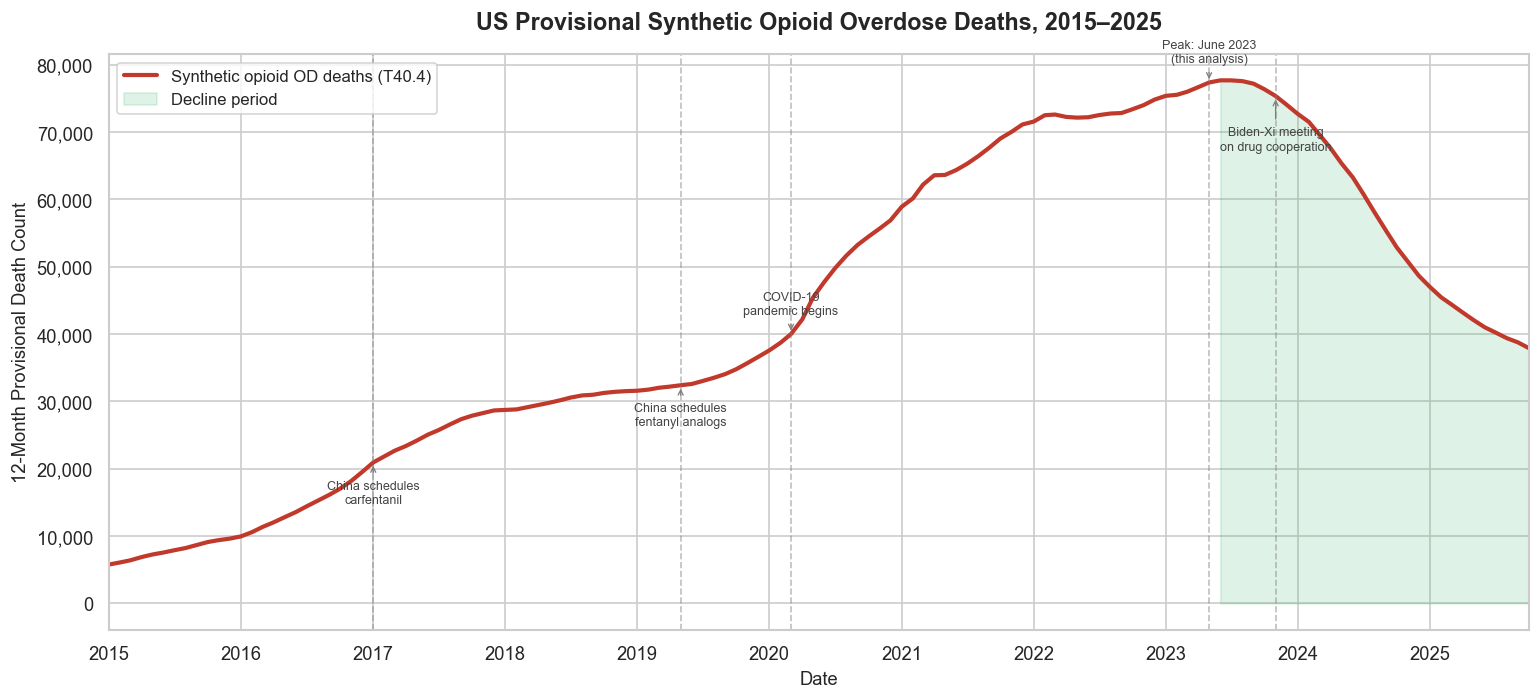

In [16]:
fig, ax = plt.subplots(figsize=(13, 6))

# ── Main trend line ────────────────────────────────────────────────────────
ax.plot(
    df_synth['date'],
    df_synth['data_value'],
    color='#c0392b',
    linewidth=2.5,
    label='Synthetic opioid OD deaths (T40.4)'
)

# ── Shaded region: the decline ─────────────────────────────────────────────
peak_date = pd.Timestamp('2023-06-01')
decline_data = df_synth[df_synth['date'] >= peak_date]
ax.fill_between(
    decline_data['date'],
    decline_data['data_value'],
    alpha=0.15,
    color='#27ae60',
    label='Decline period'
)

# ── Key event annotations ──────────────────────────────────────────────────
events = [
    ('2017-01-01', 'China schedules\ncarfentanil', -6000),
    ('2019-05-01', 'China schedules\nfentanyl analogs', -6000),
    ('2020-03-01', 'COVID-19\npandemic begins', 3000),
    ('2023-05-01', 'Peak: June 2023\n(this analysis)', 3000),
    ('2023-11-01', 'Biden-Xi meeting\non drug cooperation', -8000),
]

for date_str, label, y_offset in events:
    date = pd.Timestamp(date_str)
    # find closest data point
    closest = df_synth.iloc[(df_synth['date'] - date).abs().argsort()[:1]]
    y_val = closest['data_value'].values[0]
    ax.axvline(date, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.annotate(
        label,
        xy=(date, y_val),
        xytext=(date, y_val + y_offset),
        fontsize=7.5,
        color='#444444',
        ha='center',
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
    )

# ── Formatting ─────────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title(
    'US Provisional Synthetic Opioid Overdose Deaths, 2015–2025',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('12-Month Provisional Death Count', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(df_synth['date'].min(), df_synth['date'].max())

plt.tight_layout()
plt.savefig(FIG_DIR / '02_fig1_synthetic_opioid_national_trend.png', dpi=150)
print(' Figure 1 saved')
plt.show()

---
## 4. Figure 2 — Synthetic Opioids vs. All Drug Overdose Deaths

How much of the total overdose burden is driven by synthetic opioids specifically?
This contextualizes the fentanyl crisis within the broader overdose landscape.

Figure 2 saved


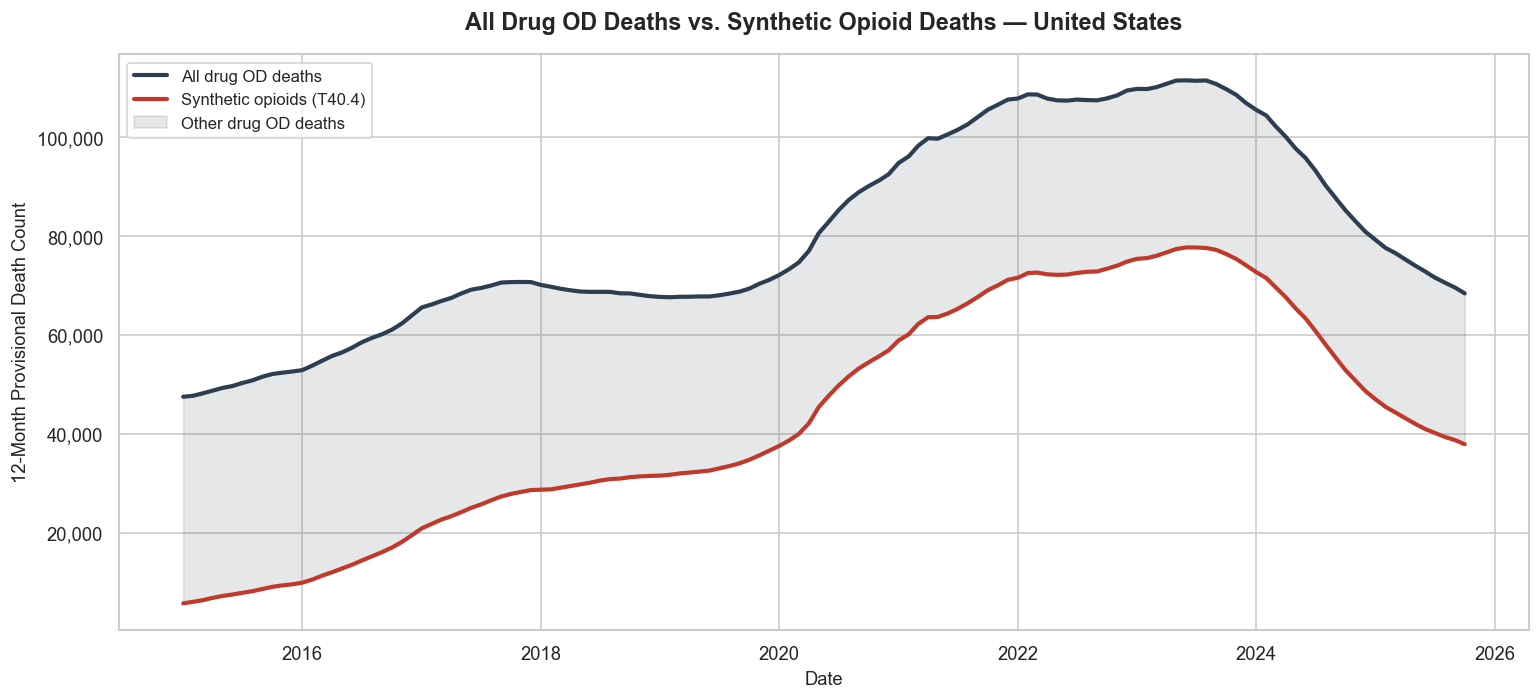

In [17]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    df_all_od['date'], df_all_od['data_value'],
    color='#2c3e50', linewidth=2.5, label='All drug OD deaths'
)
ax.plot(
    df_synth['date'], df_synth['data_value'],
    color='#c0392b', linewidth=2.5, label='Synthetic opioids (T40.4)'
)

# Fill the gap between them to show non-synthetic OD burden
# Merge on date to align series
merged = pd.merge(
    df_all_od[['date', 'data_value']].rename(columns={'data_value': 'all_od'}),
    df_synth[['date', 'data_value']].rename(columns={'data_value': 'synth'}),
    on='date', how='inner'
)
ax.fill_between(
    merged['date'], merged['synth'], merged['all_od'],
    alpha=0.12, color='#2c3e50', label='Other drug OD deaths'
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title(
    'All Drug OD Deaths vs. Synthetic Opioid Deaths — United States',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('12-Month Provisional Death Count', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_fig2_synth_vs_all_od.png', dpi=150)
print('Figure 2 saved')
plt.show()

---
## 5. Figure 3 — Multi-Drug Comparison

Testing **H2 (Demand Shift):** If users are simply switching from fentanyl to other drugs,
we would expect other drug ODD categories to *rise* as synthetic opioids *fall* post-2023.

If instead all categories decline together, that is more consistent with a broad supply
shock or a population-level reduction in drug use.

Figure 3 saved

Interpretation note:
If cocaine/meth/heroin rise while synthetic opioids fall → demand substitution (H2)
If all categories decline together → supply shock or population-level effect (H1/H3)


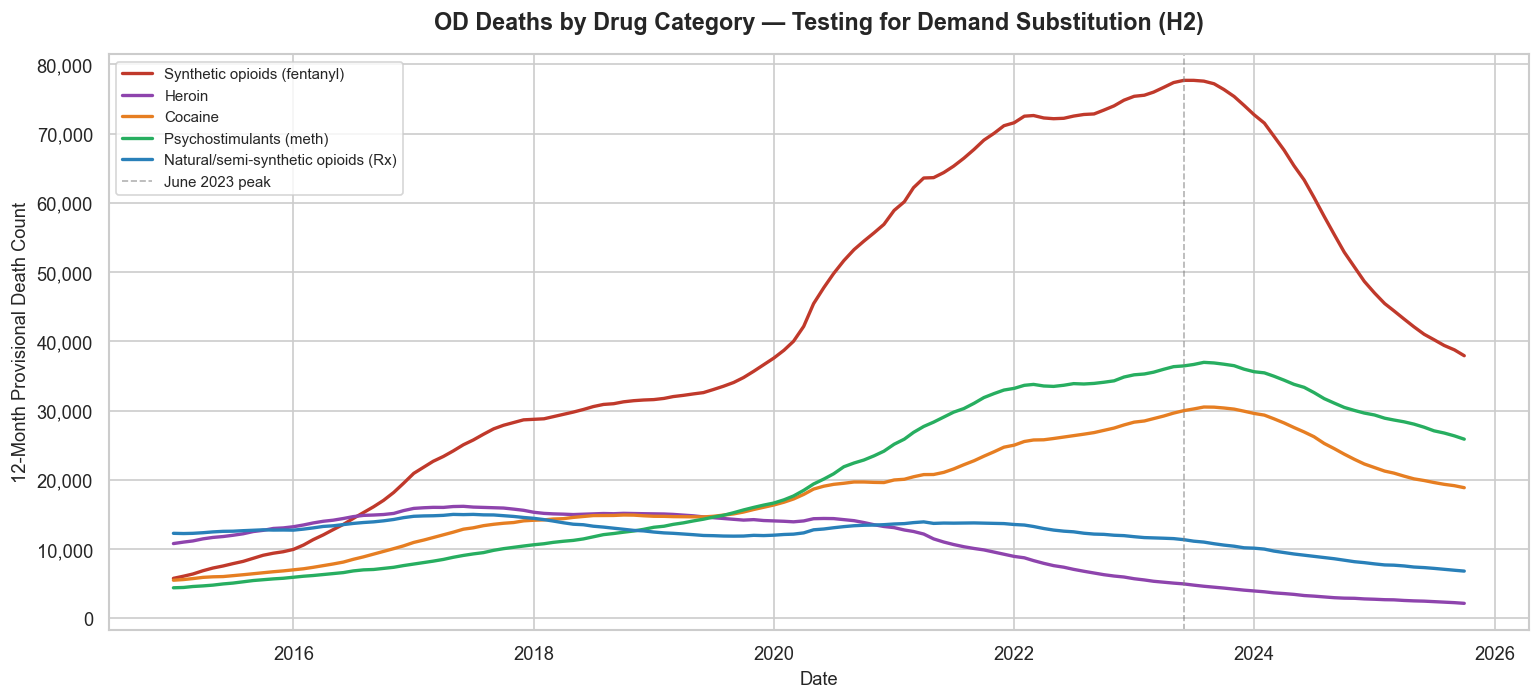

In [18]:
fig, ax = plt.subplots(figsize=(13, 6))

series = [
    (df_synth,   '#c0392b', 'Synthetic opioids (fentanyl)'),
    (df_heroin,  '#8e44ad', 'Heroin'),
    (df_cocaine, '#e67e22', 'Cocaine'),
    (df_stimul,  '#27ae60', 'Psychostimulants (meth)'),
    (df_nat_opi, '#2980b9', 'Natural/semi-synthetic opioids (Rx)'),
]

for data, color, label in series:
    ax.plot(data['date'], data['data_value'], color=color, linewidth=2, label=label)

ax.axvline(pd.Timestamp('2023-06-01'), color='gray', linestyle='--',
           alpha=0.6, linewidth=1, label='June 2023 peak')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title(
    'OD Deaths by Drug Category — Testing for Demand Substitution (H2)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('12-Month Provisional Death Count', fontsize=11)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / '02_fig3_multi_drug_comparison.png', dpi=150)
print('Figure 3 saved')
print()
print('Interpretation note:')
print('If cocaine/meth/heroin rise while synthetic opioids fall → demand substitution (H2)')
print('If all categories decline together → supply shock or population-level effect (H1/H3)')
plt.show()

---
## 6. Key Statistics — Quantifying the Rise and Fall

In [19]:
# Data Pull Percent Complete shows 100% for all months, do not need to cutoff data for accuracy concerns
print(df[df['state_name'] == 'United States'][['date', 'percent_complete']].tail(20))
print()
print(df['percent_complete'].dtype)
print(df['percent_complete'].unique()[:20])

            date  percent_complete
69400 2024-03-01               100
69401 2024-04-01               100
69402 2024-05-01               100
69403 2024-06-01               100
69404 2024-07-01               100
69405 2024-08-01               100
69406 2024-09-01               100
69407 2024-10-01               100
69408 2024-11-01               100
69409 2024-12-01               100
69410 2025-01-01               100
69411 2025-02-01               100
69412 2025-03-01               100
69413 2025-04-01               100
69414 2025-05-01               100
69415 2025-06-01               100
69416 2025-07-01               100
69417 2025-08-01               100
69418 2025-09-01               100
69419 2025-10-01               100

int64
[100]


In [20]:
# ── Find peak ─────────────────────────────────────────────────────────────
peak_row = df_synth.loc[df_synth['data_value'].idxmax()]
peak_val = peak_row['data_value']
peak_date = peak_row['date']

# ── Most recent data point ─────────────────────────────────────────────────
latest_row = df_synth.iloc[-1]
latest_val = latest_row['data_value']
latest_date = latest_row['date']

# ── Earliest available ─────────────────────────────────────────────────────
earliest_row = df_synth.iloc[0]
earliest_val = earliest_row['data_value']
earliest_date = earliest_row['date']

pct_rise = ((peak_val - earliest_val) / earliest_val) * 100
pct_decline = ((peak_val - latest_val) / peak_val) * 100

print("=" * 55)
print("SYNTHETIC OPIOID OD DEATHS — KEY STATISTICS")
print("=" * 55)
print(f"Earliest data point: {earliest_date.date()} → {earliest_val:,.0f} deaths")
print(f"Peak:                {peak_date.date()} → {peak_val:,.0f} deaths")
print(f"Latest data point:   {latest_date.date()} → {latest_val:,.0f} deaths")
print()
print(f"Rise from start to peak:      +{pct_rise:.1f}%")
print(f"Decline from peak to latest:  -{pct_decline:.1f}%")
print()
print("For reference — Vangelov et al. (2026) report:")
print("  Peak of ~76,000 deaths in 2023")
print("  Decline of >33% by end of 2024")

# ── # Synthetic opioids as % of all OD deaths at peak ──────────────────────
peak_all_od = df_all_od[df_all_od['date'] == peak_date]['data_value'].values[0]
peak_synth = peak_val
pct_of_total = (peak_synth / peak_all_od) * 100

print(f"At peak ({peak_date.date()}):")
print(f"  All OD deaths:        {peak_all_od:,.0f}")
print(f"  Synthetic opioid ODs: {peak_synth:,.0f}")
print(f"  Synthetic as % of all OD deaths: {pct_of_total:.1f}%")

SYNTHETIC OPIOID OD DEATHS — KEY STATISTICS
Earliest data point: 2015-01-01 → 5,766 deaths
Peak:                2023-06-01 → 77,695 deaths
Latest data point:   2025-10-01 → 37,920 deaths

Rise from start to peak:      +1247.5%
Decline from peak to latest:  -51.2%

For reference — Vangelov et al. (2026) report:
  Peak of ~76,000 deaths in 2023
  Decline of >33% by end of 2024
At peak (2023-06-01):
  All OD deaths:        111,466
  Synthetic opioid ODs: 77,695
  Synthetic as % of all OD deaths: 69.7%


---
## 7. Observations and Next Steps

Document what you see in the figures here before moving to notebook 03.

### Observations


**Figure 1 — Core trend:**
- Peak date confirmed at June 2023, roughly consistent with Vangelov et al May 2023 finding.
- Decline of approximately 51% from peak to latest data point

**Figure 2 — Synthetic vs. all OD:**
- Synthetic opioids account for approximately 70% of all OD deaths at peak
- The non-synthetic gap has shrunk over the period

**Figure 3 — Multi-drug comparison (H2 test):**
- After May 2023, cocaine deaths fell
- Stimulant deaths fell
- Heroin deaths fell at a decreasing rate
- Preliminary interpretation: inconsistent with pure demand substitution, but does not rule out non-overdose prone substition

### Next Steps → Notebook 03
- Break the national trend down by state
- Identify which states drove the peak and which are declining fastest
- Examine NYC separately given its unique reporting and urban concentration
- Begin geographic clustering to inform the harm reduction policy analysis (H4)